In [ ]:
from  COSMOtherm.Configfiles import Config
from COSMOtherm.funcs import gen_LIQEX_inp_file, sort_solvents_df
# from doepy import build
import pyDOE3
import subprocess
import pandas as pd
import os



temperature_range = [20, 40] # [°C] Temperature range in Celsius; From Nina [20°C, 30°C, 40°C]
massc1_lacticacid_range = [5, 20] # [g/L] Concentration of lactic acid in Fermentation Broth: From Nina [5g/L, 10g/L, 20g/L] concentration incrments in literature [50g/L, 100g/L, 150g/L, 200g/L, 250g/L]

### Conversion of mass concentration to molar fraction
M_h2o = 18.01528 # [g/mol] Molar mass of water
M_lacticacid = 90.078 # [g/mol] Molar mass of lactic acid

rho_lacticacid = 1.209 # [g/mL] Density of lactic acid
rho_h2o = 1.0 # [g/mL] Density of water

c_p_h2o = 55.5 # [mol/L] Concentration of pure water at 25°C: 
c_p_lacticacid = rho_lacticacid / M_lacticacid*(10**3) # [mol/L] Concentration of pure lactic acid at 25°C:

c1_lacticacid_range = [massc1_lacticacid_range[0]/M_lacticacid, massc1_lacticacid_range[1]/M_lacticacid] # [mol/L] Concentration of lactic acid in Fermentation Broth
c1_h2o_range = [c_p_h2o - (c_p_h2o/c_p_lacticacid)*c1_lacticacid_range[0], c_p_h2o - (c_p_h2o/c_p_lacticacid)*c1_lacticacid_range[1]] # [mol/L] Concentration of water in Fermentation Broth

x1_lacticacid_range = [c1_lacticacid_range[0]/(c1_lacticacid_range[0]+c1_h2o_range[0]), c1_lacticacid_range[1]/(c1_lacticacid_range[1]+c1_h2o_range[1])] # [mol/mol] Mole fraction of lactic acid in Fermentation Broth
# x1_h2o_range = [c1_h2o_range[0]/(c1_lacticacid_range[0]+c1_h2o_range[0]), c1_h2o_range[1]/(c1_lacticacid_range[1]+c1_h2o_range[1])] # [mol/mol] Mole fraction of water in Fermentation Broth


# Load COSMO-solvents dataframe
solvents = pd.read_csv(Config.solvents_filepath)
solvents = sort_solvents_df(solvents)
# Access the unique row identifier (index) of each row in the DataFrame

solvents_ids = solvents.index.tolist()

# Design = {
#     'temperature': temperature_range,
#     'x1_lacticacid': x1_lacticacid_range,
#     'solvent': solvents_ids
# }

# fullfact = build.full_fact(Design)
levels = [len(temperature_range), len(x1_lacticacid_range), len(solvents_ids)]
reduced_design = pyDOE3.gsd(levels=levels,reduction=4)
reduced_fullfact = pd.DataFrame(reduced_design, columns=['temperature', 'x1_lacticacid', 'solvent'])
reduced_fullfact['temperature'] = reduced_fullfact['temperature'].map({i: temperature_range[i] for i in range(len(temperature_range))})
reduced_fullfact['x1_lacticacid'] = reduced_fullfact['x1_lacticacid'].map({i: x1_lacticacid_range[i] for i in range(len(x1_lacticacid_range))})
reduced_fullfact['solvent'] = reduced_fullfact['solvent'].map({i: solvents_ids[i] for i in range(len(solvents_ids))})

reduced_fullfact = reduced_fullfact.join(solvents['COSMO_name'], on='solvent')




In [1]:
import os, glob
from COSMOtherm.Configfiles import Config, COSMOthermConfig
from COSMOtherm.funcs import sort_solvents_df
import re
import pandas as pd
import torch
import botorch
import gpytorch
from botorch.models.transforms.input import Normalize
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll

def list_files_with_extension(folder_path, file_extension):
        search_pattern = os.path.join(folder_path, f"*.{file_extension}")
        files = glob.glob(search_pattern)
        return files

# Example usage
initial_sample_files = list_files_with_extension(Config.initial_samples_path, "tab")
    
solvents = pd.read_csv(Config.solvents_filepath)
solvents = sort_solvents_df(solvents)

    
train_X=[]
train_Y=[]
for file in initial_sample_files:
        # Load the data from the file
        with open(file, 'r') as f:
            for i, line in enumerate(f):
                if i == 2:  # Line 3 (0-based index)
                    settings_line = line.strip()
                    break

        # Extract Temperature (T) and x(3) value
        temperature_match = re.search(r'T= (\d+\.\d+) K', settings_line)
        x3_match = re.search(r'x\(3\)= ([\d\.E\-]+)', settings_line)

        temperature = float(temperature_match.group(1)) if temperature_match else None
        x3_value = float(x3_match.group(1)) if x3_match else None

        # print(f"Extracted Temperature: {temperature} K, x(3): {x3_value}")
        data = pd.read_csv(file, sep=r'\s+', skiprows=4)
        solvent_name = data['Compound'][1]
        
        solvent_index = solvents[solvents['COSMO_name'] == solvent_name].index[0]
        # print(f"Solvent name:{solvent_name}; Solvent Index: {solvent_index}")
        x2_lacticacid = data['phase_2_x'][2] # [mol/mol] Mole fraction of lactic acid in solvent phase
        # print(f"y: {y}")
        # print(data.head())
        # print(data['phase_2_x'])

        train_X.append([temperature, x3_value, solvent_index])
        train_Y.append([x2_lacticacid])
        
train_X = torch.tensor(train_X, dtype=torch.float64)
train_Y = torch.tensor(train_Y, dtype=torch.float64)


In [2]:

model = botorch.models.SingleTaskGP(
        train_X=train_X, 
        train_Y=train_Y,
        input_transform=Normalize(d=train_X.shape[1]),
        outcome_transform=Standardize(m=train_Y.shape[1]),
        )

mll = gpytorch.mlls.ExactMarginalLogLikelihood(model.likelihood, model)

fit_gpytorch_mll(mll=mll)


ExactMarginalLogLikelihood(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (model): SingleTaskGP(
    (likelihood): GaussianLikelihood(
      (noise_covar): HomoskedasticNoise(
        (noise_prior): LogNormalPrior()
        (raw_noise_constraint): GreaterThan(1.000E-04)
      )
    )
    (mean_module): ConstantMean()
    (covar_module): RBFKernel(
      (lengthscale_prior): LogNormalPrior()
      (raw_lengthscale_constraint): GreaterThan(2.500E-02)
    )
    (outcome_transform): Standardize()
    (input_transform): Normalize()
  )
)

In [3]:
from botorch.acquisition import UpperConfidenceBound, ExpectedImprovement, qExpectedImprovement, LogExpectedImprovement
from botorch.optim import optimize_acqf

acqf = LogExpectedImprovement(
    model=model, 
    best_f=train_Y.max()
    )

bounds = torch.tensor([[273.15+20, 273.15+40], [0.001, 0.005], [0, 42]], dtype=torch.float64).T

candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=1,  # Number of candidates to sample
    num_restarts=50,
    raw_samples=512
    )



In [ ]:
# Round the last dimension of the candidate tensor up and down
candidate_rounded_down = candidate.clone()
candidate_rounded_up = candidate.clone()

candidate_rounded_down[-1] = torch.floor(candidate_rounded_down[-1])
candidate_rounded_up[-1] = torch.ceil(candidate_rounded_up[-1])

# Evaluate the acquisition function value for each rounded candidate
acq_value_down = acqf(candidate_rounded_down.unsqueeze(0))
acq_value_up = acqf(candidate_rounded_up.unsqueeze(0))

print(f"Acquisition value for rounded down candidate: {acq_value_down.item()}")
print(f"Acquisition value for rounded up candidate: {acq_value_up.item()}")

best_candidate = None
# Compare the acquisition function values and choose the better one
if acq_value_down > acq_value_up:
    print("Rounded down candidate is better.")
    best_candidate = candidate_rounded_down
else:
    print("Rounded up candidate is better.")
    best_candidate = candidate_rounded_up

print(f"Best candidate: {best_candidate}")



Acquisition value for rounded down candidate: -12.506569656220453
Acquisition value for rounded up candidate: -11.50559658807186


In [ ]:
next_temp = best_candidate.clone()

In [6]:
print(f"Rounded down candidate: {candidate_rounded_down}")
print(f"Rounded up candidate: {candidate_rounded_up}")

Rounded down candidate: tensor([[305.,   0.,   5.]], dtype=torch.float64)
Rounded up candidate: tensor([[306.,   1.,   6.]], dtype=torch.float64)


In [4]:
bounds.shape

torch.Size([2, 3])

In [6]:
print(bounds)
print(bounds[0, 0])
print(bounds[0, 1])

tensor([[2.9315e+02, 1.0000e-03, 0.0000e+00],
        [3.1315e+02, 5.0000e-03, 4.2000e+01]], dtype=torch.float64)
tensor(293.1500, dtype=torch.float64)
tensor(0.0010, dtype=torch.float64)


In [32]:

# Define the bounds for the input space
# bounds = torch.tensor([[train_X[:, i].min(), train_X[:, i].max()] for i in range(train_X.shape[1])], dtype=torch.float64).T
bounds = torch.tensor([[273.15+10, 273.15+50], [0.001, 0.005], [0, 42]], dtype=torch.float64).T

# Generate test points within the bounds
test_T = torch.linspace(bounds[0, 0], bounds[1, 0], 100).unsqueeze(1)  # Temperature
test_solvents = torch.linspace(bounds[0, 2], bounds[1, 2], 100).unsqueeze(1)  # Solvent index
# test_x1_lacticacid = torch.linspace(bounds[1, 0], bounds[1, 1], 100).unsqueeze(1)  # Lactic acid mole fraction

# Create a meshgrid for test_T and test_solvents with a fixed x1_lacticacid mole fraction
fixed_x1_lacticacid = train_X[:,1].max().item()  # Set the fixed mole fraction value
# fixed_x1_lacticacid = 0.001
test_T, test_solvents = torch.meshgrid(test_T.squeeze(), test_solvents.squeeze(), indexing='ij')
test_x1_lacticacid = torch.full_like(test_T, fixed_x1_lacticacid)

# test_T = torch.stack([test_T])

# Combine the meshgrid into a single tensor
test_X = torch.stack([test_T, test_x1_lacticacid, test_solvents], dim=-1).reshape(-1, 3)


In [33]:
print(fixed_x1_lacticacid)

0.0040513


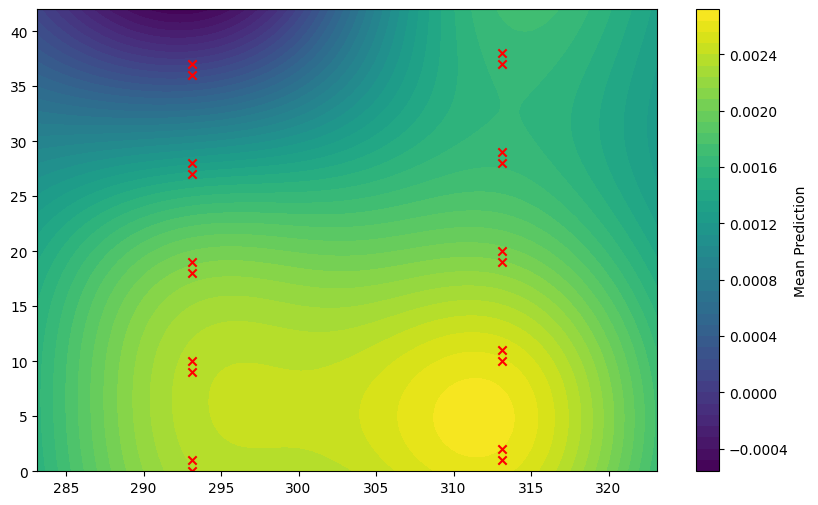

In [34]:


# test_X = draw_sobol_samples(bounds=bounds, n=1, q=100).squeeze(0)
# testX

# Make predictions
model.eval()
with torch.no_grad():
        posterior = model.posterior(test_X)
        mean = posterior.mean.squeeze(-1).numpy()
        lower, upper = posterior.mvn.confidence_region()
        lower = lower.numpy()
        upper = upper.numpy()
        
mean = mean.reshape(100, 100)
lower = lower.reshape(100, 100)
upper = upper.reshape(100, 100)

plot_T =train_X[:, 0].numpy()
plot_solvents = train_X[:, 2].numpy()
# Plot the predictions
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.contourf(test_T, test_solvents, mean, levels=50, cmap='viridis')
plt.colorbar(label='Mean Prediction')
plt.scatter(plot_T, plot_solvents, c='red', label='Training Data', marker='x')
# plt.plot(test_X[:, 0].numpy(), mean, label="Mean Prediction")
# plt.fill_between(test_X[:, 0].numpy(), lower, upper, alpha=0.3, label="Confidence Interval")
#plt.xlabel("Input Dimension 1")
#plt.ylabel("Predicted Output")
#plt.title("GP Prediction")
#plt.legend()
#plt.show()

In [9]:
train_X.shape
train_Y.shape

torch.Size([20])

In [ ]:

# Create the initial samples according to the design matrix (reduced_fullfact)
for index, row in reduced_fullfact.iterrows():
    
    print(index)
    if index >= 1:
        break
    
    # Extract the values for each parameter
    temperature = row['temperature']
    x1_lacticacid = row['x1_lacticacid']
    solvent = row['COSMO_name']
    

    # print(solvent)
    # # Create the input file for COSMO-RS
    inputfile, filename = gen_LIQEX_inp_file(
    temperature=temperature, 
    x1_lacticacid=x1_lacticacid,
    solvent=solvent,
    ctd_file=Config.ctd_file,
    cdir=Config.cdir,
    ldir=Config.ldir,
    odir=Config.odir,
    fdir=Config.fdir,
    output_folder=Config.inputfile_path
    )
    
    output_file = Config.odir+"\\"+filename[:-3]+"tab" 
    subprocess_str = Config.cosmotherm_filepath + '"' + inputfile + '"'
    
    # print(output_file)
    if os.path.exists(output_file):
        overwrite = input(f"The file '{output_file}' already exists. Do you want to overwrite it? [y/n]: ").strip().lower()
        if overwrite != 'y':
            print("Operation cancelled. The file was not overwritten. returning the existing file path and name.")
        else:
            print("Running COSMO-RS calculation and overwriting the existing file.")
            result = subprocess.run(subprocess_str, shell=True)
            print("Return code:", result.returncode)
            print("Output:", result.stdout)
            print("Error:", result.stderr)
    else:
        print("Running COSMO-RS calculation.")
        result = subprocess.run(subprocess_str, shell=True)
        print("Return code:", result.returncode)
        print("Output:", result.stdout)
        print("Error:", result.stderr)

In [ ]:
print(Config.odir+"\\"+filename)

NameError: name 'filename' is not defined

In [ ]:
from doepy import build

# design = build.frac_fact_res(4, gen=['a*b', 'b*c', 'a*c'], resolution=2)
# design = build.frac_fact_res(4, gen=['a*b', 'b*c', 'a*c'], resolution=3)

Param = {'Pressure':[40,55,70],
'Temperature':[290, 320, 350],
'Flow rate':[0.2,0.4],
'Time':[5,8]}

fullfact = build.full_fact(Param)
fullfact


/home/stefan/.cache/pypoetry/virtualenvs/thompsonsampling-XE9c7O9d-py3.12/lib/python3.12/site-packages/doepy/doe_functions.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.iloc[i][j]=r[j][int(df.iloc[i][j])]


,Pressure,Temperature,Flow rate,Time
0,40.0,290.0,0.2,5.0
1,55.0,290.0,0.2,5.0
2,70.0,290.0,0.2,5.0
3,40.0,320.0,0.2,5.0
4,55.0,320.0,0.2,5.0
5,70.0,320.0,0.2,5.0
6,40.0,350.0,0.2,5.0
7,55.0,350.0,0.2,5.0
8,70.0,350.0,0.2,5.0
9,40.0,290.0,0.4,5.0


In [27]:
import pyDOE3

design = pyDOE3.gsd(levels=[2,2,43],reduction=4)
fullfactorialdesign = pyDOE3.fullfact([2,2,43])
print(len(design))
print(len(fullfactorialdesign))
print(design)

44
172
[[ 0  0  0]
 [ 0  0  4]
 [ 0  0  8]
 [ 0  0 12]
 [ 0  0 16]
 [ 0  0 20]
 [ 0  0 24]
 [ 0  0 28]
 [ 0  0 32]
 [ 0  0 36]
 [ 0  0 40]
 [ 0  1  1]
 [ 0  1  5]
 [ 0  1  9]
 [ 0  1 13]
 [ 0  1 17]
 [ 0  1 21]
 [ 0  1 25]
 [ 0  1 29]
 [ 0  1 33]
 [ 0  1 37]
 [ 0  1 41]
 [ 1  0  1]
 [ 1  0  5]
 [ 1  0  9]
 [ 1  0 13]
 [ 1  0 17]
 [ 1  0 21]
 [ 1  0 25]
 [ 1  0 29]
 [ 1  0 33]
 [ 1  0 37]
 [ 1  0 41]
 [ 1  1  2]
 [ 1  1  6]
 [ 1  1 10]
 [ 1  1 14]
 [ 1  1 18]
 [ 1  1 22]
 [ 1  1 26]
 [ 1  1 30]
 [ 1  1 34]
 [ 1  1 38]
 [ 1  1 42]]


In [24]:
build.frac_fact_res(d=Param, res=2)

/home/stefan/.cache/pypoetry/virtualenvs/thompsonsampling-XE9c7O9d-py3.12/lib/python3.12/site-packages/doepy/doe_functions.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.iloc[i][j]=r[j][int(df.iloc[i][j])]


,Pressure,Temperature,Flow rate,Time
0,40.0,290.0,0.2,5.0
1,70.0,290.0,0.2,5.0
2,40.0,350.0,0.2,5.0
3,70.0,350.0,0.2,5.0
4,40.0,290.0,0.4,5.0
5,70.0,290.0,0.4,5.0
6,40.0,350.0,0.4,5.0
7,70.0,350.0,0.4,5.0
8,40.0,290.0,0.2,8.0
9,70.0,290.0,0.2,8.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

c_p_h2o = np.linspace(0, 55.5, 100) # [mol/L] Concentration of water in Fermentation Broth
c_p_lacticacid = np.linspace(0, 1.209 / M_lacticacid*(10**3), 100) # [mol/L] Concentration of lactic acid in Fermentation Broth
x1_h2o = np.linspace(0, 1, 100) # [mol/L] Concentration of water in Fermentation Broth

c_p_lacticacid = c_p_lacticacid[::-1]

plt.plot(x1_h2o, c_p_h2o, label='Water')
plt.plot(x1_h2o, c_p_lacticacid, label='Lactic Acid')